# Задание 8: Симуляция марковской цепи

Генерируем синтетические ДНК-последовательности по матрице переходов
и сравниваем эмпирические частоты динуклеотидов с исходной матрицей P.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

## Матрица переходов P из задания 5

In [7]:
nucleotides = ['A', 'C', 'G', 'T']
nuc_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

record = next(SeqIO.parse("GCA_029856635.1_ASM2985663v1_genomic.fna", "fasta"))
seq = ''.join(c for c in str(record.seq).upper() if c in 'ACGT')

dinuc_counts = np.zeros((4, 4), dtype=int)
for i in range(len(seq) - 1):
    dinuc_counts[nuc_index[seq[i]], nuc_index[seq[i+1]]] += 1

P = dinuc_counts / dinuc_counts.sum(axis=1, keepdims=True)

## 1. Функция generate_sequence

На каждом шаге выбираем следующий нуклеотид по строке P через `numpy.random.choice`.

In [8]:
def generate_sequence(P, length, start_state):
    """
    Генерирует последовательность длиной length,
    начиная с нуклеотида start_state ('A', 'C', 'G' или 'T').
    """
    nuc_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    nucleotides = ['A', 'C', 'G', 'T']

    current = nuc_index[start_state]
    result = [start_state]

    for _ in range(length - 1):
        current = np.random.choice(4, p=P[current])
        result.append(nucleotides[current])

    return ''.join(result)


test_seq = generate_sequence(P, 50, 'A')
print(f"Тест (50 нт): {test_seq}")

Тест (50 нт): ATTTCACCAGCTAGTTTTTCGAAAAAAATATATTTTATTTTCTCGATAAG


## 2. Генерируем 10 последовательностей по 1000 нт

In [9]:
np.random.seed(42)
N_SEQS  = 10
SEQ_LEN = 1000

generated = []
for i in range(N_SEQS):
    start = np.random.choice(['A', 'C', 'G', 'T'])
    generated.append(generate_sequence(P, SEQ_LEN, start))

print(f"Сгенерировано {N_SEQS} последовательностей по {SEQ_LEN} нт.")
print(f"Пример: {generated[0][:60]}")

Сгенерировано 10 последовательностей по 1000 нт.
Пример: GTATGCACCAGATTATGGAAGCATAAGCTGTTGATGCAAAGGTACATCAGATGCTTCGCT


## 3–4. Частоты динуклеотидов — сравнение с P

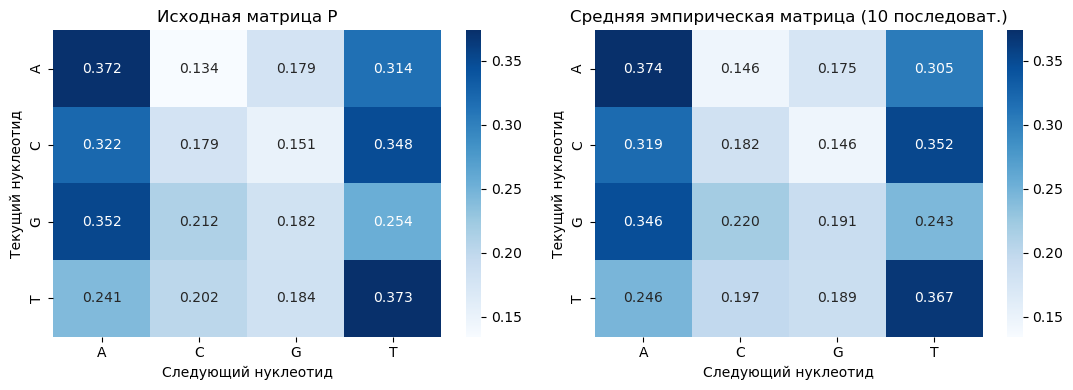

Максимальное отклонение: 0.0112
Среднее отклонение:      0.0061

Вывод: матрицы очень близки — марковская модель хорошо воспроизводит
частоты динуклеотидов исходной последовательности.


In [10]:
def dinucleotide_matrix(seq):
    counts = np.zeros((4, 4), dtype=float)
    for i in range(len(seq) - 1):
        counts[nuc_index[seq[i]], nuc_index[seq[i+1]]] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return counts / row_sums


empirical_matrices = [dinucleotide_matrix(s) for s in generated]
mean_empirical = np.mean(empirical_matrices, axis=0)

# Тепловые карты
vmin = min(P.min(), mean_empirical.min())
vmax = max(P.max(), mean_empirical.max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(P, annot=True, fmt=".3f",
            xticklabels=nucleotides, yticklabels=nucleotides,
            cmap='Blues', ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title("Исходная матрица P")
axes[0].set_xlabel("Следующий нуклеотид")
axes[0].set_ylabel("Текущий нуклеотид")

sns.heatmap(mean_empirical, annot=True, fmt=".3f",
            xticklabels=nucleotides, yticklabels=nucleotides,
            cmap='Blues', ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title("Средняя эмпирическая матрица (10 последоват.)")
axes[1].set_xlabel("Следующий нуклеотид")
axes[1].set_ylabel("Текущий нуклеотид")

plt.tight_layout()
plt.savefig("markov_simulation_heatmap.png", dpi=150)
plt.show()

diff = np.abs(P - mean_empirical)
print(f"Максимальное отклонение: {diff.max():.4f}")
print(f"Среднее отклонение:      {diff.mean():.4f}")
print()
print("Вывод: матрицы очень близки — марковская модель хорошо воспроизводит")
print("частоты динуклеотидов исходной последовательности.")